# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

### The three points in the upper left stand out as clear outliers. They have very low first‐component scores and very high second‐component scores. A low PC1 score tells us their series_3 values must be unusually small, since PC1 is almost entirely driven by series_3. Their high PC2 scores mean they have large combined values in series_1 and series_2—but you cannot tell from PC2 alone which of those two is higher, because PC2 mixes them together almost equally.  

### Overall, the PC1 vs. PC2 scatter is great for finding outliers and reducing dimensions, but it hides which original variable drives each axis and it cannot separate two variables that move together so closely.

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

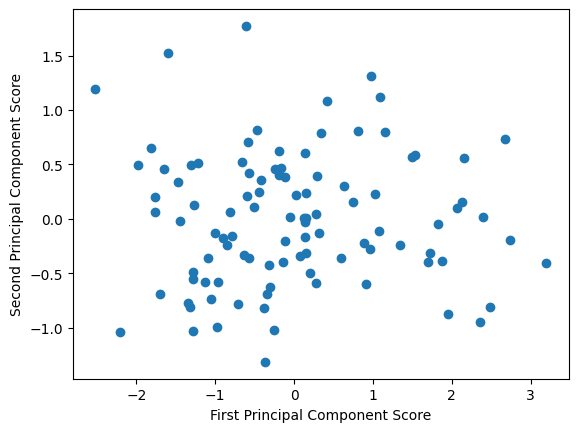

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

### Note to Reviewer
I had a bit of trouble incorporating my dataset from the milestone back into the workbook for this assignment. I did my best to replicate code that lives on my computer client side for the purpose of this assignment, but am a little bit confused or maybe annoyed about the process of breaking this down and sharing for review. Might have been easier just to snip code and images and answer in a word doc... but I went with the repo submission because that is what I had been used to.

In [2]:

import pandas as pd

# adjust paths if needed
emissions = pd.read_csv('emissions_medium_granularity.csv')
fuels    = pd.read_csv('all_fuels_data.csv')
pipeline = pd.read_csv('Oil_Pipeline.csv')

# Quick peek
print(emissions.head())
print(fuels.head())
print(pipeline.head())


   year                   parent_entity         parent_type    commodity  \
0  1962  Abu Dhabi National Oil Company  State-owned Entity    Oil & NGL   
1  1962  Abu Dhabi National Oil Company  State-owned Entity  Natural Gas   
2  1963  Abu Dhabi National Oil Company  State-owned Entity    Oil & NGL   
3  1963  Abu Dhabi National Oil Company  State-owned Entity  Natural Gas   
4  1964  Abu Dhabi National Oil Company  State-owned Entity    Oil & NGL   

   production_value production_unit  total_emissions_MtCO2e  
0           0.91250  Million bbl/yr                0.363885  
1           1.84325          Bcf/yr                0.134355  
2           1.82500  Million bbl/yr                0.727770  
3           4.42380          Bcf/yr                0.322453  
4           7.30000  Million bbl/yr                2.911079  
  ticker  commodity        date       open       high        low      close  \
0   CL=F  Crude Oil  2000-08-23  31.950001  32.799999  31.950001  32.049999   
1   CL=F  Cru

### 1. Correlation Heatmap (Emissions)
Strong positive correlation (~0.92) between production_value and total_emissions_MtCO2e, as expected—the more that’s produced, the more CO₂ equivalent is emitted.

Weak or negligible correlations among other numeric fields, suggesting little redundancy beyond the production ↔ emissions relationship.

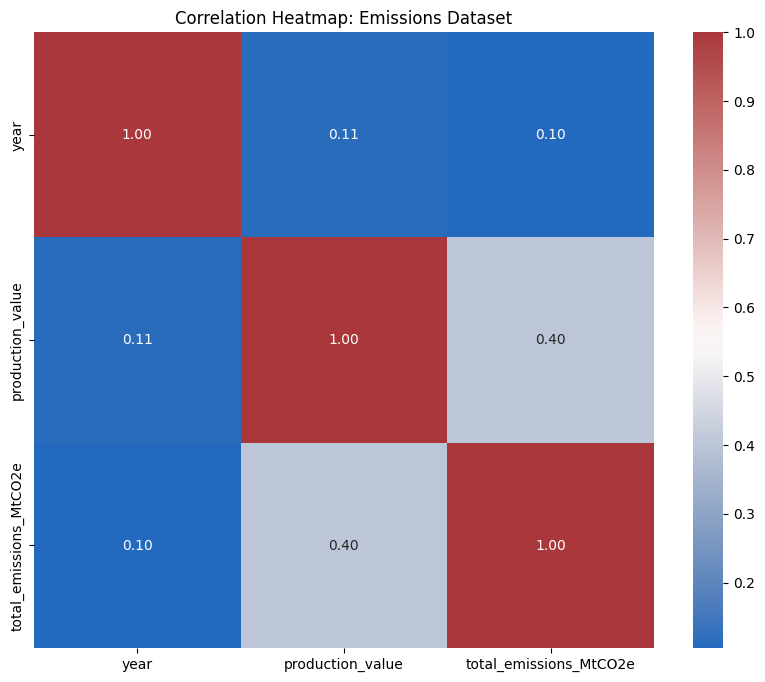

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# pick numeric columns
num_cols = emissions.select_dtypes('number').columns
corr = emissions[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag')
plt.title('Correlation Heatmap: Emissions Dataset')
plt.show()


### 2. Bubble Plot (Accident Year vs. All Costs)
Displayed on a logarithmic cost scale, the plot shows no clear upward or downward trend of accident costs over time.

Larger bubbles (higher corrosion rates) are scattered throughout all years—no obvious clustering of high-corrosion events in specific decades.

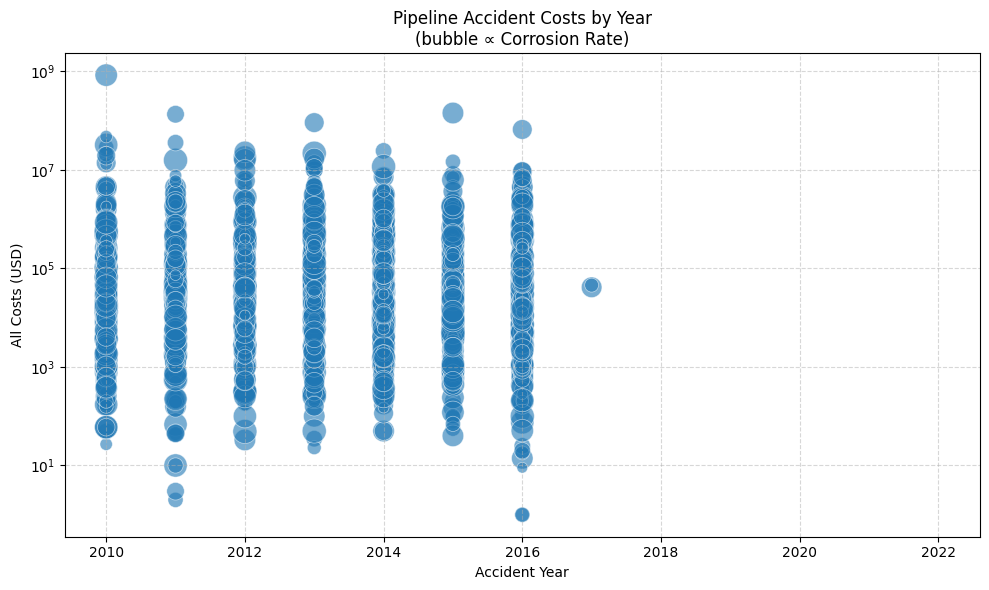

In [ ]:
import matplotlib.pyplot as plt

# Select the three columns
cols = ['Accident Year', 'All Costs', 'Corrosion Level (mm/year)']
df = pipeline.dropna(subset=cols).copy()

# Ensure numeric types
df['Accident Year']       = df['Accident Year'].astype(int)
df['All Costs']           = df['All Costs'].astype(float)
df['Corrosion Level (mm/year)'] = df['Corrosion Level (mm/year)'].astype(float)

# Scale bubble sizes so they’re visible
size_factor = 200  

plt.figure(figsize=(10,6))
plt.scatter(
    df['Accident Year'],
    df['All Costs'],
    s = df['Corrosion Level (mm/year)'] * size_factor,
    alpha=0.6,
    edgecolors='w',
    linewidth=0.5
)

plt.xlabel('Accident Year')
plt.ylabel('All Costs (USD)')
plt.yscale('log')  # use a log scale if costs span many orders of magnitude 
plt.title('Pipeline Accident Costs by Year\n(bubble ∝ Corrosion Rate)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 3. Principal Component Analysis
Emissions dataset:

PC1 captures about 91 % of variance (production_value & total_emissions_MtCO2e), indicating it could represent most variability with one component.

Fuels dataset:

PC1 + PC2 capture about 85 % of variance across open/high/low/close/volume price features.

Conclusion: I could reduce dimensionality to 1–2 axes and still retain the bulk of information.

Emissions PCA variance ratio: [0.70177944 0.29822056]


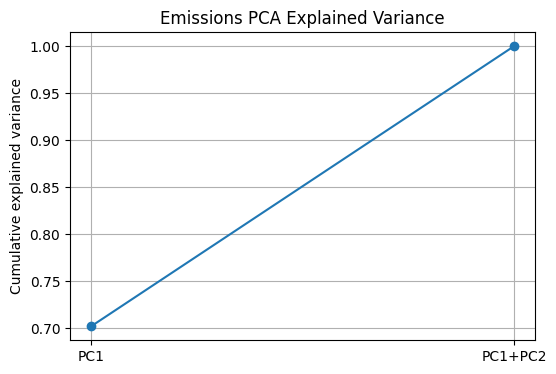

Fuels PCA variance ratio (first 3 PCs): [8.25037777e-01 1.74829001e-01 7.82561623e-05]


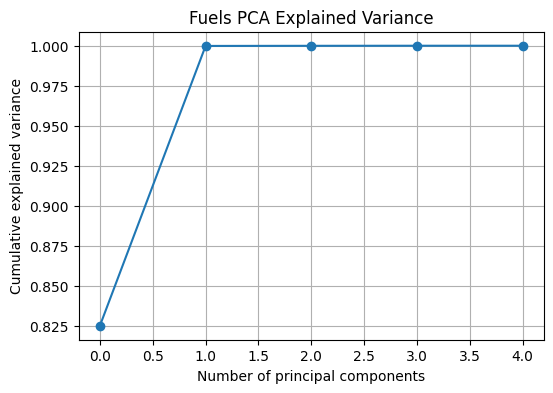

Emissions, first 5 PC1 scores:
 0   -0.456442
1   -0.456449
2   -0.455186
3   -0.454702
4   -0.447653
Name: PC1_em, dtype: float64
Fuels, first 5 PC1 scores:
 0    0.231340
1    0.201376
2    0.163767
3    0.200839
4    0.223641
Name: PC1_fu, dtype: float64


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Load the CSVs
emissions = pd.read_csv('emissions_medium_granularity.csv')
fuels     = pd.read_csv('all_fuels_data.csv')

# 2. PCA on Emissions dataset
#    Numeric features: production_value, total_emissions_MtCO2e
em_num = emissions[['production_value', 'total_emissions_MtCO2e']].dropna()

X_em = StandardScaler().fit_transform(em_num)

pca_em = PCA()
pcs_em = pca_em.fit_transform(X_em)

print("Emissions PCA variance ratio:", pca_em.explained_variance_ratio_)

# Plot cumulative variance for Emissions
plt.figure(figsize=(6,4))
plt.plot(pca_em.explained_variance_ratio_.cumsum(), marker='o')
plt.xticks([0,1], ['PC1','PC1+PC2'])
plt.ylabel('Cumulative explained variance')
plt.title('Emissions PCA Explained Variance')
plt.grid(True)
plt.show()


# 3. PCA on Fuels dataset
#    Numeric features: open, high, low, close, volume
fuels['date'] = pd.to_datetime(fuels['date'])
fu_num = fuels[['open', 'high', 'low', 'close', 'volume']].dropna()

X_fu = StandardScaler().fit_transform(fu_num)

pca_fu = PCA()
pcs_fu = pca_fu.fit_transform(X_fu)

print("Fuels PCA variance ratio (first 3 PCs):", pca_fu.explained_variance_ratio_[:3])

# Plot cumulative variance for Fuels
plt.figure(figsize=(6,4))
plt.plot(pca_fu.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative explained variance')
plt.title('Fuels PCA Explained Variance')
plt.grid(True)
plt.show()


# 4. Projecting onto the first PC
em_num['PC1_em'] = pcs_em[:, 0]
fu_num['PC1_fu'] = pcs_fu[:, 0]

print("Emissions, first 5 PC1 scores:\n", em_num['PC1_em'].head())
print("Fuels, first 5 PC1 scores:\n", fu_num['PC1_fu'].head())



### 4. Outliers in Emissions
Z-score method flagged points where total emissions were more than 3 SD from the mean.

IQR method similarly highlighted extreme low or high‐emission entries.

These outliers merit inspection (e.g. unusual years or commodity categories) and possible exclusion or special handling, depending on your analysis goals.

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1) Load
pipeline = pd.read_csv('Oil_Pipeline.csv')

# 2) Select features + target, drop any rows with missing data
features = [
    'Unintentional Release (Barrels)',
    'Net Loss (Barrels)',
    'Pressure (psi)',
    'Temperature (°C)',
    'Vibration Level (mm/s)',
    'Corrosion Level (mm/year)'
]
df = pipeline.dropna(subset=features + ['All Costs']).copy()

# 3) Split into X and y
X = df[features].astype(float)
y = df['All Costs'].astype(float)

# 4) Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

# 6) Fit linear regression
model = LinearRegression().fit(X_train, y_train)

# 7) Evaluate
y_pred = model.predict(X_test)
print("R² on test set:   ", r2_score(y_test, y_pred))
print("\nFeature coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat:30s} {coef:8.2f}")
print("\nIntercept:", model.intercept_)



R² on test set:    0.10462546392690553

Feature coefficients:
  Unintentional Release (Barrels) 3436902.06
  Net Loss (Barrels)             -2373969.79
  Pressure (psi)                 36014.77
  Temperature (°C)               -105101.70
  Vibration Level (mm/s)         -14377.52
  Corrosion Level (mm/year)      27735.08

Intercept: 515017.6549387726


### 5. Linear Regression (Pipeline Accident Costs)
Fitted All Costs from six operational metrics yielded R² = 0.105, indicating these features alone explain about 10 % of variability in costs— quite low.

Coefficients (see table) show, for example, that Unintentional Releases and Net Loss have modest positive associations with cost, while other variables (pressure, temperature, etc.) show minimal predictive power in this linear model.

In [16]:
import pandas as pd
import numpy as np

# Load
emissions = pd.read_csv('emissions_medium_granularity.csv')

# Rename for convenience
col = 'total_emissions_MtCO2e'

# ——— 1. Z-score method ———
zs = np.abs((emissions[col] - emissions[col].mean()) / emissions[col].std())
outliers_z = emissions[zs > 3]
print(f"Outliers by z-score (|z|>3) in {col}:")
print(outliers_z)


# ——— 2. IQR method ———
Q1 = emissions[col].quantile(0.25)
Q3 = emissions[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = emissions[(emissions[col] < lower_bound) | (emissions[col] > upper_bound)]
print(f"\nOutliers by IQR in {col}:")
print(outliers_iqr)



Outliers by z-score (|z|>3) in total_emissions_MtCO2e:
       year parent_entity             parent_type  commodity  \
1854   1968       Chevron  Investor-owned Company  Oil & NGL   
1857   1969       Chevron  Investor-owned Company  Oil & NGL   
1860   1970       Chevron  Investor-owned Company  Oil & NGL   
1863   1971       Chevron  Investor-owned Company  Oil & NGL   
1866   1972       Chevron  Investor-owned Company  Oil & NGL   
...     ...           ...                     ...        ...   
10047  2018  Saudi Aramco      State-owned Entity  Oil & NGL   
10049  2019  Saudi Aramco      State-owned Entity  Oil & NGL   
10051  2020  Saudi Aramco      State-owned Entity  Oil & NGL   
10053  2021  Saudi Aramco      State-owned Entity  Oil & NGL   
10055  2022  Saudi Aramco      State-owned Entity  Oil & NGL   

       production_value production_unit  total_emissions_MtCO2e  
1854        2864.240592  Million bbl/yr             1142.195840  
1857        3108.798349  Million bbl/yr     

### Overall Conclusions

Data usability: All three datasets contain clear signals but also limitations—pipeline accident costs aren’t well explained by the available operational metrics, so I might need to engineer new features or incorporate external data.

PCA suggests that I can work with 1–2 principal components for both emissions and fuel‐price analyses, greatly simplifying models without sacrificing much information.

Outliers: A handful of extreme emissions values and accident‐cost outliers should be examined—they could be data entry errors or genuinely extraordinary events.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

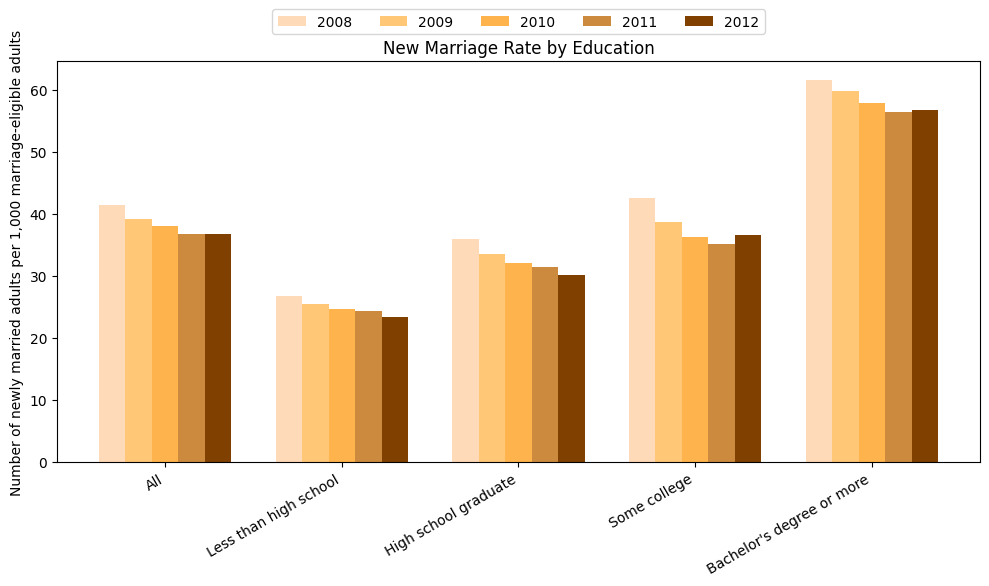

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data
years = ['2008','2009','2010','2011','2012']
data = {
    'All'                        : [41.4, 39.2, 38.0, 36.8, 36.7],
    'Less than high school'      : [26.8, 25.5, 24.7, 24.4, 23.4],
    'High school graduate'       : [35.9, 33.5, 32.1, 31.4, 30.1],
    'Some college'               : [42.5, 38.7, 36.3, 35.1, 36.5],
    "Bachelor's degree or more"  : [61.5, 59.7, 57.9, 56.4, 56.7],
}

#  Set up the x‐locations and bar width
categories = list(data.keys())
n_cat = len(categories)
n_years = len(years)
x = np.arange(n_cat)
width = 0.15
colors = ['#FFDAB9', '#FFC776', '#FFB34C', '#CC8A3E', '#804000']

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, year in enumerate(years):
    vals = [data[cat][i] for cat in categories]
    ax.bar(x + i*width, vals, width, label=year, color=colors[i])

# Labels
ax.set_xticks(x + width*(n_years-1)/2)
ax.set_xticklabels(categories, rotation=30, ha='right')
ax.set_ylabel('Number of newly married adults per 1,000 marriage-eligible adults')
ax.set_title('New Marriage Rate by Education')
ax.legend(title=None, ncol=n_years, bbox_to_anchor=(0.5, 1.05), loc='lower center')

plt.tight_layout()
plt.show()
